In [3]:
import findspark
findspark.init()

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Student Grade Prediction") \
    .getOrCreate()

In [4]:
df = spark.read.csv(
    "C:/Users/chira/OneDrive/Desktop/student-por.csv",
    header=True,
    inferSchema=True
)

df.show(5)

+------+---+---+-------+-------+-------+----+----+-------+--------+------+--------+----------+---------+--------+---------+------+----+----------+-------+------+--------+--------+------+--------+-----+----+----+------+--------+---+---+---+
|school|sex|age|address|famsize|Pstatus|Medu|Fedu|   Mjob|    Fjob|reason|guardian|traveltime|studytime|failures|schoolsup|famsup|paid|activities|nursery|higher|internet|romantic|famrel|freetime|goout|Dalc|Walc|health|absences| G1| G2| G3|
+------+---+---+-------+-------+-------+----+----+-------+--------+------+--------+----------+---------+--------+---------+------+----+----------+-------+------+--------+--------+------+--------+-----+----+----+------+--------+---+---+---+
|    GP|  F| 18|      U|    GT3|      A|   4|   4|at_home| teacher|course|  mother|         2|        2|       0|      yes|    no|  no|        no|    yes|   yes|      no|      no|     4|       3|    4|   1|   1|     3|       4|  0| 11| 11|
|    GP|  F| 17|      U|    GT3|      T|

In [14]:
df.describe().show()

+-------+------------------+-----------------+------------------+
|summary|        test_score|       attendance|       final_grade|
+-------+------------------+-----------------+------------------+
|  count|               649|              649|               649|
|   mean|11.484591679506934|96.34052388289676|11.906009244992296|
| stddev|2.7323637385956454|4.640758808397165| 3.230656242804805|
|    min|               2.0|               68|                 0|
|    max|              18.5|              100|                19|
+-------+------------------+-----------------+------------------+



In [15]:
df.toPandas().corr()

,test_score,attendance,final_grade
test_score,1.000000,0.140433,0.904888
attendance,0.140433,1.000000,0.091379
final_grade,0.904888,0.091379,1.000000


In [5]:
df.printSchema()
df.describe().show()

root
 |-- school: string (nullable = true)
 |-- sex: string (nullable = true)
 |-- age: integer (nullable = true)
 |-- address: string (nullable = true)
 |-- famsize: string (nullable = true)
 |-- Pstatus: string (nullable = true)
 |-- Medu: integer (nullable = true)
 |-- Fedu: integer (nullable = true)
 |-- Mjob: string (nullable = true)
 |-- Fjob: string (nullable = true)
 |-- reason: string (nullable = true)
 |-- guardian: string (nullable = true)
 |-- traveltime: integer (nullable = true)
 |-- studytime: integer (nullable = true)
 |-- failures: integer (nullable = true)
 |-- schoolsup: string (nullable = true)
 |-- famsup: string (nullable = true)
 |-- paid: string (nullable = true)
 |-- activities: string (nullable = true)
 |-- nursery: string (nullable = true)
 |-- higher: string (nullable = true)
 |-- internet: string (nullable = true)
 |-- romantic: string (nullable = true)
 |-- famrel: integer (nullable = true)
 |-- freetime: integer (nullable = true)
 |-- goout: integer (null

In [6]:
df = df.dropna()

In [7]:
from pyspark.sql.functions import col

# Create attendance from absences
df = df.withColumn("attendance", 100 - col("absences"))

# Create test_score using G1 and G2
df = df.withColumn(
    "test_score",
    (col("G1") + col("G2")) / 2
)

# Final dataset
df = df.select(
    "test_score",
    "attendance",
    col("G3").alias("final_grade")
)

df.show(5)

+----------+----------+-----------+
|test_score|attendance|final_grade|
+----------+----------+-----------+
|       5.5|        96|         11|
|      10.0|        98|         11|
|      12.5|        94|         12|
|      14.0|       100|         14|
|      12.0|       100|         13|
+----------+----------+-----------+
only showing top 5 rows



In [8]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=["test_score", "attendance"],
    outputCol="features"
)

data = assembler.transform(df)

In [9]:
train_data, test_data = data.randomSplit([0.8, 0.2], seed=42)

In [10]:
from pyspark.ml.regression import LinearRegression

lr = LinearRegression(
    featuresCol="features",
    labelCol="final_grade"
)

model = lr.fit(train_data)

In [11]:
predictions = model.transform(test_data)

predictions.select(
    "test_score",
    "attendance",
    "final_grade",
    "prediction"
).show(10)

+----------+----------+-----------+-----------------+
|test_score|attendance|final_grade|       prediction|
+----------+----------+-----------+-----------------+
|       2.5|       100|          0|2.190777224620756|
|       4.5|       100|          0|4.333728415642817|
|       5.5|        96|         11|5.505173964240651|
|       6.5|        88|          7|6.776589465925287|
|       6.5|       100|          0|6.476679606664879|
|       7.0|        98|          8|7.062402380963796|
|       7.0|       100|          8|7.012417404420395|
|       7.5|        88|          5|7.848065061436317|
|       7.5|       100|          0|7.548155202175909|
|       7.5|       100|          8|7.548155202175909|
+----------+----------+-----------+-----------------+
only showing top 10 rows



In [12]:
from pyspark.ml.evaluation import RegressionEvaluator

# RMSE
rmse_eval = RegressionEvaluator(
    labelCol="final_grade",
    predictionCol="prediction",
    metricName="rmse"
)

# R2
r2_eval = RegressionEvaluator(
    labelCol="final_grade",
    predictionCol="prediction",
    metricName="r2"
)

rmse = rmse_eval.evaluate(predictions)
r2 = r2_eval.evaluate(predictions)

print("RMSE:", rmse)
print("R2 Score:", r2)

RMSE: 1.5252353964751213
R2 Score: 0.8272796763732316


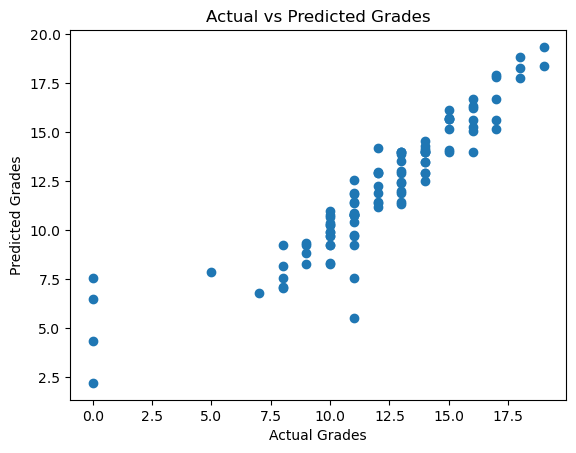

In [13]:
pdf = predictions.select("final_grade", "prediction").toPandas()

import matplotlib.pyplot as plt

plt.scatter(pdf["final_grade"], pdf["prediction"])
plt.xlabel("Actual Grades")
plt.ylabel("Predicted Grades")
plt.title("Actual vs Predicted Grades")
plt.show()

In [16]:
print("Coefficients:", model.coefficients)
print("Intercept:", model.intercept)

Coefficients: [1.0714755955110307,-0.024992488271700676]
Intercept: 2.011337063013247


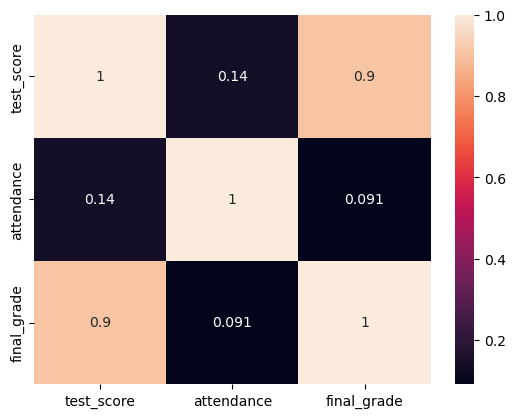

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.toPandas().corr(), annot=True)
plt.show()